# Accessibility Analysis

## Load route results

In this notebook we analyse the routing results.

We compute summary statistics for:
- school districts
- individual schools

Other than that, we create simple maps of accessibility

In [24]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

routes = gpd.read_file(
    "../data/processed/route_results.gpkg",
    layer="route_results"
)

print("Rows:", len(routes))
routes.head()

Rows: 85051


,Adresse,district_code,district_name_address,address_id,school_name,district_name_school,school_x,school_y,euclidean_dist_m,origin_node,destination_node,shortest_dist_m,safest_cost,safest_dist_m,detour_m,detour_ratio,geometry
0,A-Vej 13,281053,Nordøstamager Skole,0,Nordøstamager Skole,Nordøstamager Skole,727492.38,6175022.64,1800.112982,1579394496,5460266144,1860.553,5522.122,1860.553,0.000,1,POINT (728901.860 6176142.360)
1,A.C. Meyers Vænge 1,281060,Sluseholmen Skole,1,Sluseholmen Skole,Sluseholmen Skole,723282.82,6172147.96,1028.066690,9934420177,8056451400,1462.706,3220.037,2295.228,832.522,1.569165642309527,POINT (722956.550 6173122.880)
2,A.C. Meyers Vænge 2,281060,Sluseholmen Skole,2,Sluseholmen Skole,Sluseholmen Skole,723282.82,6172147.96,1073.328721,311362582,8056451400,1473.939,3075.265,2170.261,696.322,1.472422535803721,POINT (722940.540 6173165.250)
3,A.C. Meyers Vænge 3,281060,Sluseholmen Skole,3,Sluseholmen Skole,Sluseholmen Skole,723282.82,6172147.96,1018.977117,9934420180,8056451400,1424.086,2567.774,1522.014,97.928,1.068765509948135,POINT (722950.720 6173111.300)
4,A.C. Meyers Vænge 4,281060,Sluseholmen Skole,4,Sluseholmen Skole,Sluseholmen Skole,723282.82,6172147.96,1083.809253,9934420178,8056451400,1493.681,2910.287,2264.253,770.572,1.515887930555453,POINT (722928.310 6173172.150)


## Clean routing results

We remove rows where routing failed or values are missing (if any)

In [25]:
routes_clean = routes.dropna(subset=[
    "shortest_dist_m",
    "safest_dist_m"
]).copy()

print("Clean rows:", len(routes_clean))

Clean rows: 84910


## Check whether some columns are objects, or if they are all numeric

In [26]:
print(routes_clean[[
    "shortest_dist_m",
    "safest_dist_m",
    "detour_m",
    "detour_ratio"
]].dtypes)

shortest_dist_m    float64
safest_dist_m      float64
detour_m           float64
detour_ratio        object
dtype: object


## Change the columns that arent numeric into numeric

In [27]:
numeric_cols = [
    "detour_ratio"
]

for col in numeric_cols:
    routes_clean[col] = pd.to_numeric(routes_clean[col], errors="coerce")

print(routes_clean[numeric_cols].dtypes)

detour_ratio    float64
dtype: object


## Compute district-level accessibility metrics

We aggregate routing results by school district.

Metrics are:
- mean shortest distance in meters
- mean safest distance in meters
- mean detour in meters
- mean detour ratio


In [28]:
district_stats = (
    routes_clean.groupby(["district_code", "district_name_address"])
    .agg(
        mean_shortest_m=("shortest_dist_m", "mean"),
        mean_safest_m=("safest_dist_m", "mean"),
        mean_detour_m=("detour_m", "mean"),
        mean_detour_ratio=("detour_ratio", "mean"),
        count_addresses=("address_id", "count")
    )
    .reset_index()
)

district_stats.head()

,district_code,district_name_address,mean_shortest_m,mean_safest_m,mean_detour_m,mean_detour_ratio,count_addresses
0,101001,Den Classenske Legatskole,985.344283,1269.285337,283.941054,1.272784,2830
1,101003,Nyboder Skole,855.405662,1244.435275,389.029612,1.632880,1894
2,101005,Sølvgades Skole,1257.294225,1847.879590,590.585365,1.554193,1554
3,101007,Nørrebro Park Skole,420.909473,501.762943,80.853470,1.176948,609
4,101008,Blågård Skole,673.072764,1380.552960,707.480196,2.004259,1374


## Compute school-level accessibility metrics

This shows variation between schools.

In [29]:
school_stats = (
    routes_clean.groupby("school_name")
    .agg(
        mean_shortest_m=("shortest_dist_m", "mean"),
        mean_safest_m=("safest_dist_m", "mean"),
        mean_detour_m=("detour_m", "mean"),
        mean_detour_ratio=("detour_ratio", "mean"),
        count_addresses=("address_id", "count")
    )
    .reset_index()
)

school_stats.head()

,school_name,mean_shortest_m,mean_safest_m,mean_detour_m,mean_detour_ratio,count_addresses
0,Amager Fælled Skole,292.141971,494.549165,202.407194,1.556472,315
1,Arena Skole og Fritid,1620.131848,1692.939936,72.808088,1.039941,864
2,Bavnehøj Skole,1416.610121,2187.452290,770.842169,1.506950,997
3,Bellahøj Skole,581.042640,767.714135,186.671495,1.277066,1026
4,Blågård Skole,673.072764,1380.552960,707.480196,2.004259,1374


## Join district statistics to spatial polygons

This allows us to map accessibility.

In [30]:
districts = gpd.read_file(
    "../data/processed/core_layers.gpkg",
    layer="school_districts"
)


districts["udd_distri"] = districts["udd_distri"].astype(str)

district_map = districts.merge(
    district_stats,
    left_on="udd_distri",
    right_on="district_code",
    how="left"
)

district_map.head()

,temakode,temanavn,objekt_id,versions_i,systid_fra,systid_til,oprettet,cvr_kode,cvr_navn,kommunekod,...,udd_delomr,udd_delo_1,geometry,district_code,district_name_address,mean_shortest_m,mean_safest_m,mean_detour_m,mean_detour_ratio,count_addresses
0,5710,t_5710_born_skole_dis_t,caebf878-f997-11ea-8ef4-06d09fa510f4,4af5ce08-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,NaN,NaN,"POLYGON ((724468.727 6174207.618, 724824.483 6...",101059,Skolen på Islands Brygge,1548.098436,1878.850243,330.751807,1.235320,1598
1,5710,t_5710_born_skole_dis_t,caec40da-f997-11ea-8efa-06d09fa510f4,4af9587a-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,NaN,NaN,"MULTIPOLYGON (((723566.615 6172586.107, 723670...",280129,Skolen i Sydhavnen,681.847536,1144.218258,462.370722,1.703160,724
2,5710,t_5710_born_skole_dis_t,caf771da-f997-11ea-8f2a-06d09fa510f4,4afad1e6-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,NaN,NaN,"POLYGON ((724798.236 6169075.917, 724761.682 6...",281474,Distrikt Ørestad,923.421062,1217.567930,294.146868,1.379058,3651
3,5710,t_5710_born_skole_dis_t,cae99b50-f997-11ea-8eca-06d09fa510f4,4afbefd6-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,NaN,NaN,"POLYGON ((723570.181 6175053.926, 723568.928 6...",101586,Skolen ved Dybbølsbro,895.128085,1562.415005,667.286920,1.703593,1301
4,5710,t_5710_born_skole_dis_t,caf6d3e2-f997-11ea-8f20-06d09fa510f4,4afd1a5a-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,NaN,NaN,"POLYGON ((724592.495 6177975.285, 724787.236 6...",101043,Øster Farimagsgades Skole,420.331454,719.037626,298.706172,1.954525,967


## Map: Average safest distance per district

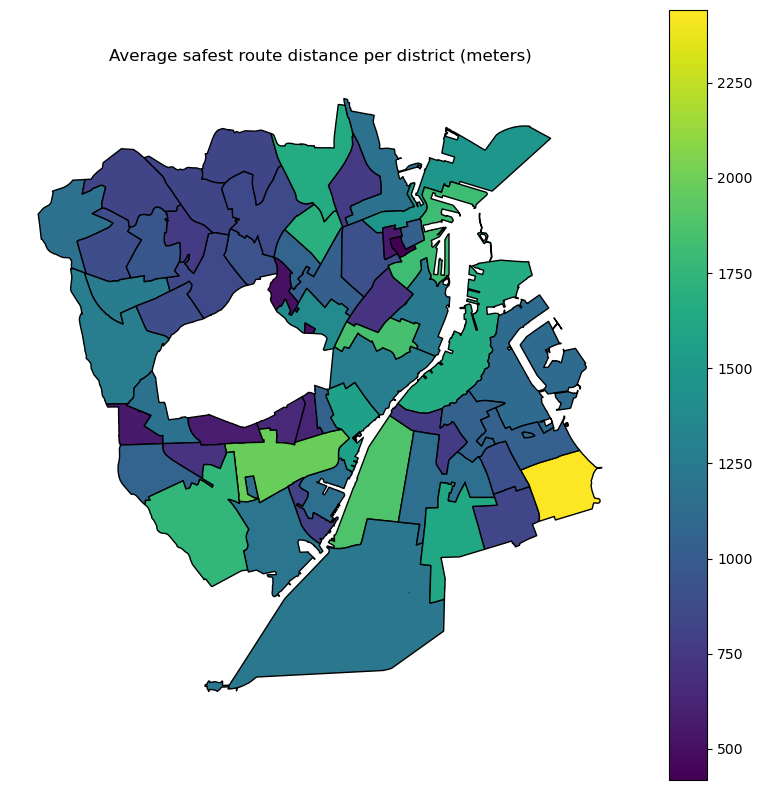

In [31]:
fig, ax = plt.subplots(figsize=(10,10))

district_map.plot(
    column="mean_safest_m",
    cmap="viridis",
    legend=True,
    ax=ax,
    edgecolor="black"
)

plt.title("Average safest route distance per district (meters)")
plt.axis("off")
plt.show()

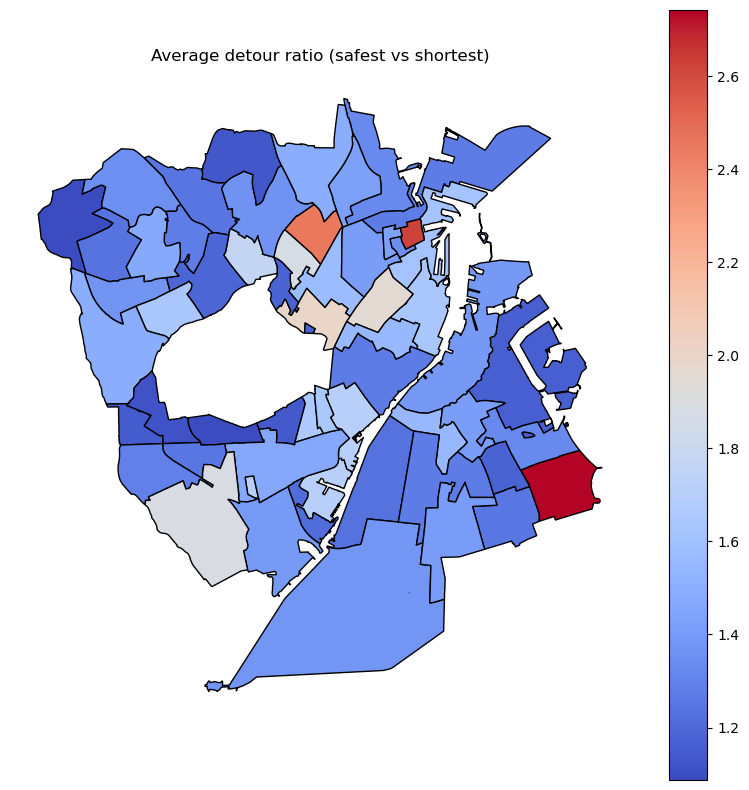

In [32]:
fig, ax = plt.subplots(figsize=(10,10))

district_map.plot(
    column="mean_detour_ratio",
    cmap="coolwarm",
    legend=True,
    ax=ax,
    edgecolor="black"
)

plt.title("Average detour ratio (safest vs shortest)")
plt.axis("off")
plt.show()

## Save results for further analysis and visualisation

In [33]:
district_map.to_file(
    "../data/processed/analysis_layers.gpkg",
    layer="district_accessibility",
    driver="GPKG"
)

school_stats.to_csv("../data/processed/school_stats.csv", index=False)